<a href="https://colab.research.google.com/github/Sinchana-2208/air_quality/blob/main/SinchanaShetty_MinorProject_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()


Saving Housing.csv to Housing.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
#Basic Information About Dataset
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (545, 13)

Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-n

In [4]:
# Converting the price to lakhs
df['price_lakhs'] = df['price'] / 100000

# Creating the price categories
bins = [0, 25, 50, 75, 100, float('inf')]
labels = ['0-25 Lakhs', '26-50 Lakhs', '51-75 Lakhs',
          '76-100 Lakhs', '>100 Lakhs']

df['price_category'] = pd.cut(
    df['price_lakhs'],
    bins=bins,
    labels=labels
)

# Counting the houses
price_counts = df['price_category'].value_counts().sort_index()

print("Number of Houses in Each Price Range:")
print(price_counts)

Number of Houses in Each Price Range:
price_category
0-25 Lakhs       32
26-50 Lakhs     318
51-75 Lakhs     148
76-100 Lakhs     39
>100 Lakhs        8
Name: count, dtype: int64


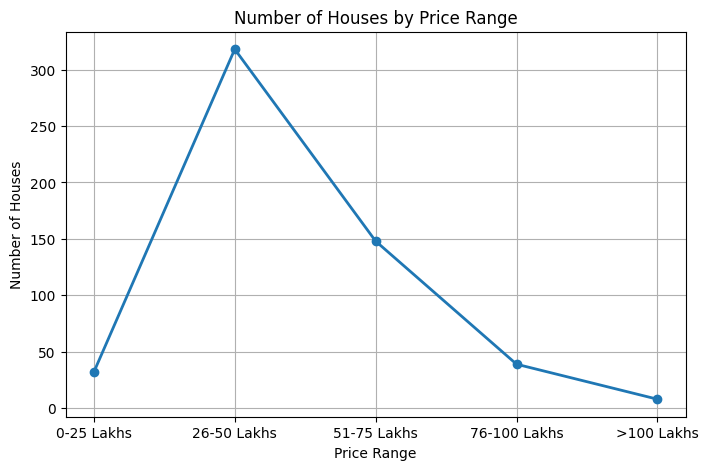

In [5]:
#plotting a line graph for the above details
plt.figure(figsize=(8,5))

plt.plot(
    price_counts.index,
    price_counts.values,
    marker='o',
    linewidth=2
)

plt.title("Number of Houses by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Houses")
plt.grid(True)

plt.show()

In [6]:
#Average House Prices for AC and Non-AC Houses
ac_avg_price = df.groupby('airconditioning')['price'].mean()

print("Average House Price:")
print(ac_avg_price)

Average House Price:
airconditioning
no     4.191940e+06
yes    6.013221e+06
Name: price, dtype: float64


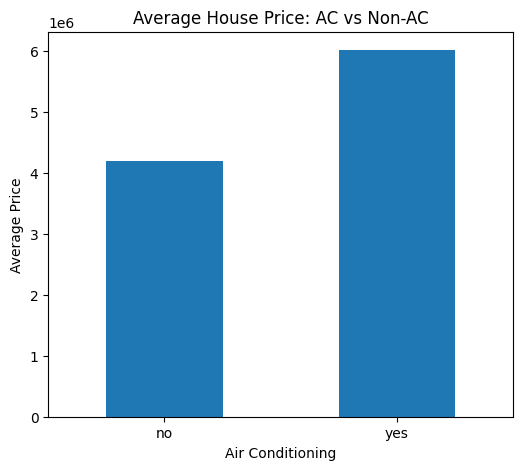

In [7]:
#Bar chart for the above details
plt.figure(figsize=(6,5))

ac_avg_price.plot(kind='bar')

plt.title("Average House Price: AC vs Non-AC")
plt.xlabel("Air Conditioning")
plt.ylabel("Average Price")
plt.xticks(rotation=0)

plt.show()

In [8]:
#Relationship Between Parking and House Price
parking_price = df.groupby('parking')['price'].mean()

print("Average Price Based on Parking Spaces:")
print(parking_price)

Average Price Based on Parking Spaces:
parking
0    4.136017e+06
1    5.190389e+06
2    5.896328e+06
3    5.867167e+06
Name: price, dtype: float64


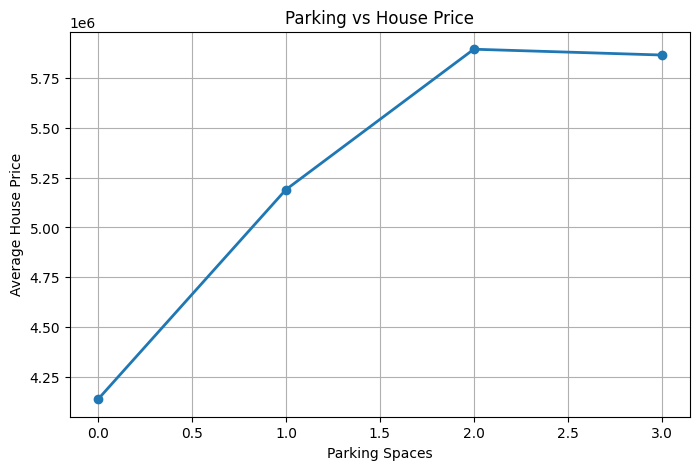

In [9]:
#Visualising the relationship between parking and house price
plt.figure(figsize=(8,5))

plt.plot(
    parking_price.index,
    parking_price.values,
    marker='o',
    linewidth=2
)

plt.title("Parking vs House Price")
plt.xlabel("Parking Spaces")
plt.ylabel("Average House Price")
plt.grid(True)

plt.show()

In [10]:
#Price Gap Analysis
group1 = df[
    (df['area'] < 5000) &
    (df['prefarea'] == 'no')
]

group2 = df[
    (df['area'] > 5000) &
    (df['prefarea'] == 'yes')
]

avg_price_group1 = group1['price'].mean()
avg_price_group2 = group2['price'].mean()

price_gap = avg_price_group2 - avg_price_group1

print("Average Price (<5000 sqft & No Preferred Area):")
print(round(avg_price_group1, 2))

print("\nAverage Price (>5000 sqft & Preferred Area):")
print(round(avg_price_group2, 2))

print("\nPrice Gap:")
print(round(price_gap, 2))

Average Price (<5000 sqft & No Preferred Area):
3827671.56

Average Price (>5000 sqft & Preferred Area):
6546807.69

Price Gap:
2719136.13


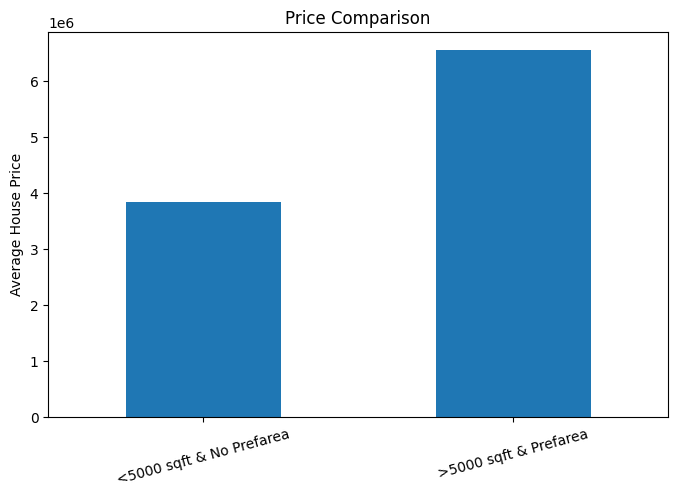

In [11]:
#Comparison Bar Graph
comparison = pd.Series({
    '<5000 sqft & No Prefarea': avg_price_group1,
    '>5000 sqft & Prefarea': avg_price_group2
})

plt.figure(figsize=(8,5))

comparison.plot(kind='bar')

plt.title("Price Comparison")
plt.ylabel("Average House Price")
plt.xticks(rotation=15)

plt.show()

In [12]:
#Summary of the whole project
print("========== PROJECT SUMMARY ==========")

print("\n1. Number of Houses in Different Price Ranges")
print(price_counts)

print("\n2. Average House Price (AC vs Non-AC)")
print(ac_avg_price)

print("\n3. Average House Price by Parking Spaces")
print(parking_price)

print("\n4. Price Gap Analysis")
print("Average Price (<5000 sqft & No Prefarea):", round(avg_price_group1,2))
print("Average Price (>5000 sqft & Prefarea):", round(avg_price_group2,2))
print("Price Gap:", round(price_gap,2))

========== PROJECT SUMMARY ==========

1. Number of Houses in Different Price Ranges
price_category
0-25 Lakhs       32
26-50 Lakhs     318
51-75 Lakhs     148
76-100 Lakhs     39
>100 Lakhs        8
Name: count, dtype: int64

2. Average House Price (AC vs Non-AC)
airconditioning
no     4.191940e+06
yes    6.013221e+06
Name: price, dtype: float64

3. Average House Price by Parking Spaces
parking
0    4.136017e+06
1    5.190389e+06
2    5.896328e+06
3    5.867167e+06
Name: price, dtype: float64

4. Price Gap Analysis
Average Price (<5000 sqft & No Prefarea): 3827671.56
Average Price (>5000 sqft & Prefarea): 6546807.69
Price Gap: 2719136.13
